In [ ]:
import pandas as pd

In [66]:
!git clone https://github.com/No-Country-simulation/G9-LATAM-Team-12

fatal: destination path 'G9-LATAM-Team-12' already exists and is not an empty directory.


In [70]:
%cd G9-LATAM-Team-12

[Errno 2] No such file or directory: 'G9-LATAM-Team-12'
/content/G9-LATAM-Team-12
remote: Enumerating objects: 16, done.
remote: Counting objects: 100% (15/15), done.
remote: Compressing objects: 100% (11/11), done.
remote: Total 12 (delta 4), reused 2 (delta 1), pack-reused 0 (from 0)
Unpacking objects: 100% (12/12), 762.09 KiB | 1.84 MiB/s, done.
From https://github.com/No-Country-simulation/G9-LATAM-Team-12
   9ca57a6..21c394e  main       -> origin/main
   dcfed2e..1925b2a  feature    -> origin/feature
Updating 9ca57a6..21c394e
Fast-forward
 .idea/.gitignore                                   |    10 +
 .idea/G9-LATAM-Team-12.iml                         |     9 +
 .idea/compiler.xml                                 |    21 +
 .idea/encodings.xml                                |     6 +
 .idea/jarRepositories.xml                          |    20 +
 .idea/misc.xml                                     |    15 +
 .idea/modules.xml                                  |     8 +
 .idea/remote-ta

In [71]:
df = pd.read_csv("/content/G9-LATAM-Team-12/data/household_energy_consumption.csv")
df.head()

,Household_ID,Date,Energy_Consumption_kWh,Household_Size,Avg_Temperature_C,Has_AC,Peak_Hours_Usage_kWh
0,H00001,2025-04-01,8.4,4,17.8,No,3.2
1,H00001,2025-04-02,7.9,4,17.3,No,2.8
2,H00001,2025-04-03,9.2,4,18.6,No,3.0
3,H00001,2025-04-04,7.9,4,18.2,No,2.7
4,H00001,2025-04-05,9.6,4,11.9,No,3.2


In [72]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90000 entries, 0 to 89999
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Household_ID            90000 non-null  object 
 1   Date                    90000 non-null  object 
 2   Energy_Consumption_kWh  90000 non-null  float64
 3   Household_Size          90000 non-null  int64  
 4   Avg_Temperature_C       90000 non-null  float64
 5   Has_AC                  90000 non-null  object 
 6   Peak_Hours_Usage_kWh    90000 non-null  float64
dtypes: float64(3), int64(1), object(3)
memory usage: 4.8+ MB


In [73]:
df.shape

(90000, 7)

In [74]:
df.describe()

,Energy_Consumption_kWh,Household_Size,Avg_Temperature_C,Peak_Hours_Usage_kWh
count,90000.000000,90000.000000,90000.000000,90000.000000
mean,10.571988,3.487811,17.505802,4.319557
std,5.519494,1.709761,2.491621,2.531432
min,0.500000,1.000000,10.000000,0.200000
25%,6.000000,2.000000,15.800000,2.300000
50%,10.400000,3.000000,17.500000,4.000000
75%,14.800000,5.000000,19.200000,6.000000
max,20.000000,6.000000,25.000000,10.000000


In [75]:
df.isnull().sum().sort_values(ascending=False)

,0
Household_ID,0
Date,0
Energy_Consumption_kWh,0
Household_Size,0
Avg_Temperature_C,0
Has_AC,0
Peak_Hours_Usage_kWh,0


In [ ]:
df['Has_AC'].unique()

array(['No', 'Yes'], dtype=object)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
for col in df.select_dtypes(include='object'):
  print(col)
  print(df[col].value_counts())
  print()

Household_ID
Household_ID
H12857    8
H08564    7
H08565    7
H08566    7
H08567    7
         ..
H04291    7
H04292    7
H04293    7
H04294    7
H04282    7
Name: count, Length: 12857, dtype: int64

Date
Date
2025-04-01    12857
2025-04-02    12857
2025-04-03    12857
2025-04-04    12857
2025-04-05    12857
2025-04-06    12857
2025-04-07    12857
2025-04-08        1
Name: count, dtype: int64

Has_AC
Has_AC
No     45508
Yes    44492
Name: count, dtype: int64



In [ ]:
df[df['Date'] == '2025-04-08']

,Household_ID,Date,Energy_Consumption_kWh,Household_Size,Avg_Temperature_C,Has_AC,Peak_Hours_Usage_kWh
89999,H12857,2025-04-08,7.2,2,18.2,No,2.6


In [ ]:
house = df[df['Date'] == '2025-04-08'] ['Household_ID'].iloc[0]

df[df['Household_ID'] == 'H12857'].sort_values('Date')

,Household_ID,Date,Energy_Consumption_kWh,Household_Size,Avg_Temperature_C,Has_AC,Peak_Hours_Usage_kWh
89992,H12857,2025-04-01,4.8,2,19.1,No,1.5
89993,H12857,2025-04-02,3.8,2,20.6,No,1.4
89994,H12857,2025-04-03,3.8,2,17.2,No,1.4
89995,H12857,2025-04-04,5.0,2,19.3,No,1.5
89996,H12857,2025-04-05,5.3,2,16.1,No,1.7
89997,H12857,2025-04-06,4.3,2,14.6,No,1.5
89998,H12857,2025-04-07,7.2,2,18.2,No,2.6
89999,H12857,2025-04-08,7.2,2,18.2,No,2.6


Se detectó un único registro correspondiente a la fecha 2025-04-08, mientras que el período de estudio del dataset comprende del 2025-04-01 al 2025-04-07. Al tratarse de un valor aislado fuera del rango temporal analizado y debido a que es un duplicado de los valores registrados en la fecha 2025-04-07 para esa misma casa se decide excluirlo.

In [ ]:
df = df[df['Date'] != '2025-04-08']

In [ ]:
df.shape

(89999, 7)

In [ ]:
df.describe()

,Energy_Consumption_kWh,Household_Size,Avg_Temperature_C,Peak_Hours_Usage_kWh
count,89999.000000,89999.000000,89999.000000,89999.000000
mean,10.572025,3.487828,17.505795,4.319576
std,5.519514,1.709764,2.491633,2.531440
min,0.500000,1.000000,10.000000,0.200000
25%,6.000000,2.000000,15.800000,2.300000
50%,10.400000,3.000000,17.500000,4.000000
75%,14.800000,5.000000,19.200000,6.000000
max,20.000000,6.000000,25.000000,10.000000


In [ ]:
consumo_total = df.groupby('Household_ID')['Energy_Consumption_kWh'].sum()
consumo_total.head(10)

,Energy_Consumption_kWh
Household_ID,
H00001,59.6
H00002,87.4
H00003,53.6
H00004,125.8
H00005,92.7
H00006,34.0
H00007,57.6
H00008,81.0
H00009,55.3


In [ ]:
resumen = (
    df.groupby('Household_ID').agg({
        'Energy_Consumption_kWh':'sum',
        'Household_Size':'first',
        'Avg_Temperature_C':'first',
        'Has_AC':'first',
        'Peak_Hours_Usage_kWh':'mean'
    })
    .reset_index()
)
resumen.head()

,Household_ID,Energy_Consumption_kWh,Household_Size,Avg_Temperature_C,Has_AC,Peak_Hours_Usage_kWh
0,H00001,59.6,4,17.8,No,2.985714
1,H00002,87.4,5,18.0,No,4.500000
2,H00003,53.6,3,18.2,No,2.685714
3,H00004,125.8,5,16.8,Yes,8.085714
4,H00005,92.7,5,14.7,No,4.414286


In [ ]:
resumen.shape

(12857, 6)

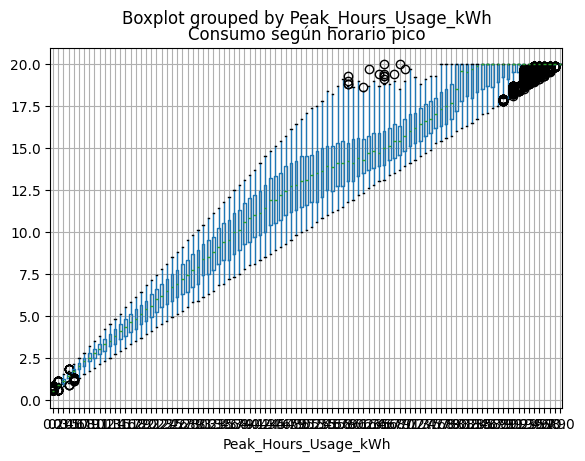

In [ ]:
import matplotlib.pyplot as plt

df.boxplot(column='Energy_Consumption_kWh',
by='Peak_Hours_Usage_kWh')
plt.title('Consumo según horario pico')
plt.show()